# Phase Shift to Quantum Capacitance

This notebook walks through the new helpers in `qpd.theory.readout`,
which invert what we measure on the cavity (a phase shift) into
what we want to interpret physically (a change in quantum
capacitance). The chain has two steps:

1. measured cavity phase shift $\Delta\varphi$
   $\;\to\;$ resonator frequency shift $\Delta f_r$
2. resonator frequency shift $\Delta f_r$
   $\;\to\;$ change in quantum capacitance $\Delta C_Q$

Per issue #3, the readout drive does not need to sit on either
parity-resolved resonance — the inversion handles arbitrary drive
placement.


In [1]:
%matplotlib inline
from qpd import (
    QPD,
    phase_shift_to_frequency_shift,
    frequency_shift_to_quantum_capacitance,
    kappa_from_quality_factors,
)
import numpy as np
import matplotlib.pyplot as plt


# Step 1: phase shift $\to$ frequency shift

We work in the **resonator basis**: the qubit is a small
capacitive load that shifts the bare resonator frequency $f_r$
by an amount $\Delta f_r$ depending on the qubit state. The
loaded cavity, driven at frequency $f_d$, has the standard
Lorentzian phase response:

$$
\varphi(\Delta_d) \;=\; \arctan\!\left(\frac{2\,\Delta_d}{\kappa}\right),
\qquad \Delta_d = f_d - f_r,
$$

where $\kappa$ is the loaded linewidth (FWHM). When the qubit
shifts the cavity by $\Delta f$, the drive's effective detuning
becomes $\Delta_d - \Delta f$ and the measured phase becomes
$\arctan(2(\Delta_d - \Delta f)/\kappa)$.

The measured *change* in phase $\Delta\varphi$ inverts in
closed form:

$$
\Delta f \;=\; \Delta_d \;-\; \frac{\kappa}{2}\,
       \tan\!\left[\arctan\!\left(\tfrac{2\Delta_d}{\kappa}\right) + \Delta\varphi\right].
$$

This is exactly what `phase_shift_to_frequency_shift` evaluates.


## Visualise the cavity response


## Getting κ from measured quality factors

The phase inversion needs the **loaded** linewidth κ. From a
standard hanger / notch fit you typically pull internal and
coupling Q factors `Q_i`, `Q_c`. They combine in parallel:

$$
\frac{1}{Q_\text{loaded}} = \frac{1}{Q_i} + \frac{1}{Q_c},
\qquad \kappa = \frac{f_r}{Q_\text{loaded}}.
$$

`kappa_from_quality_factors` is a one-liner that returns κ in Hz.


In [2]:
# Quality factors from a typical QPD3 readout-resonator fit:
f_r = 7.0e9
q_i = 1.0e5
q_c = 2.5e4

kappa = kappa_from_quality_factors(f_r, q_i, q_c)
print(f'Q_loaded = {1.0 / (1.0/q_i + 1.0/q_c):.0f}')
print(f'kappa    = {kappa/1e3:.1f} kHz   (FWHM)')


Q_loaded = 20000
kappa    = 350.0 kHz   (FWHM)


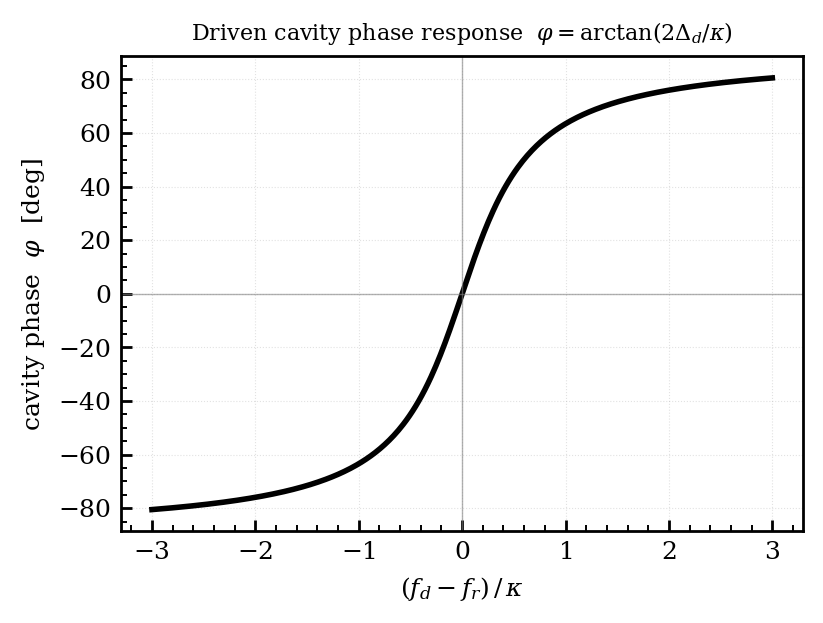

In [3]:
kappa = 1.0e6  # 1 MHz loaded linewidth
det_axis = np.linspace(-3 * kappa, 3 * kappa, 401)
phase = np.arctan(2 * det_axis / kappa)

with plt.style.context(QPD._style_path):
    fig, ax = plt.subplots(figsize=(4, 3))
    ax.plot(det_axis / kappa, np.degrees(phase), color='black', lw=2)
    ax.axhline(0, color='gray', lw=0.5, alpha=0.6)
    ax.axvline(0, color='gray', lw=0.5, alpha=0.6)
    ax.set_xlabel(r'$(f_d - f_r)\,/\,\kappa$')
    ax.set_ylabel(r'cavity phase  $\varphi$  [deg]')
    ax.set_title(r'Driven cavity phase response  $\varphi=\arctan(2\Delta_d/\kappa)$',
                 fontsize=8)
    ax.minorticks_on(); ax.grid(alpha=0.3)
    plt.show()


Sensitivity $d\varphi/d\Delta f$ peaks at $\Delta_d = 0$ and
falls as $1/(1 + (2\Delta_d/\kappa)^2)$ off resonance. So picking
the readout frequency *somewhere in the middle* between the two
parity branches — instead of on either resonance — is a real
trade-off: smaller phase signal per unit $\Delta f$ but symmetric
response.


## Round-trip sanity check

Pick a true $\Delta f$ and a drive detuning $\Delta_d$, compute
the phase change forward, then invert.


In [4]:
kappa = 1.0e6
drive_detuning = 0.4e6     # 400 kHz off resonance
true_df = 50e3             # 50 kHz cavity shift

phi_old = np.arctan(2 * drive_detuning / kappa)
phi_new = np.arctan(2 * (drive_detuning - true_df) / kappa)
delta_phi = phi_new - phi_old

df_recovered = phase_shift_to_frequency_shift(
    delta_phi, kappa_hz=kappa, drive_detuning_hz=drive_detuning,
)
print(f'Δφ measured  = {np.degrees(delta_phi):+.4f} deg')
print(f'Δf true      = {true_df/1e3:+.3f} kHz')
print(f'Δf recovered = {df_recovered/1e3:+.3f} kHz')


Δφ measured  = -3.6678 deg
Δf true      = +50.000 kHz
Δf recovered = +50.000 kHz


Vectorise it: how does sensitivity depend on the drive placement
for a fixed measured $\Delta\varphi$?


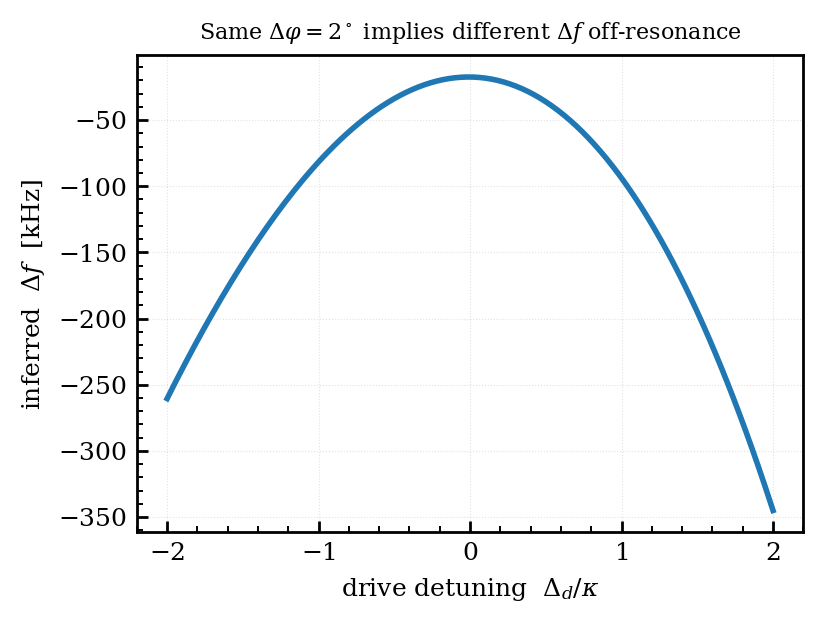

In [5]:
delta_phi_fixed = np.radians(2.0)  # 2 degree phase shift
detunings = np.linspace(-2 * kappa, 2 * kappa, 201)
df_inferred = phase_shift_to_frequency_shift(
    delta_phi_fixed, kappa, detunings,
)

with plt.style.context(QPD._style_path):
    fig, ax = plt.subplots(figsize=(4, 3))
    ax.plot(detunings / kappa, df_inferred / 1e3, lw=2, color='tab:blue')
    ax.set_xlabel(r'drive detuning  $\Delta_d / \kappa$')
    ax.set_ylabel(r'inferred  $\Delta f$  [kHz]')
    ax.set_title(r'Same $\Delta\varphi=2^\circ$ implies different $\Delta f$ off-resonance',
                 fontsize=8)
    ax.minorticks_on(); ax.grid(alpha=0.3)
    plt.show()


# Step 2: frequency shift $\to$ quantum capacitance

In the resonator basis the qubit acts as a small capacitive load
on the cavity. To leading order in $\Delta C_Q / C_r$,

$$
\frac{\Delta f_r}{f_r} \;\approx\; -\frac{\Delta C_Q}{2\, C_r},
\qquad |\Delta C_Q| \ll C_r.
$$

`frequency_shift_to_quantum_capacitance` is just a one-liner that
implements this map.


In [6]:
f_r = 7.0e9         # bare resonator frequency [Hz]
c_r = 1.0e-13       # 0.1 pF effective resonator capacitance

# A resonator that drops 50 kHz means the qubit added how much C_Q?
delta_cq = frequency_shift_to_quantum_capacitance(true_df, f_r, c_r)
print(f'Δf_r = {true_df/1e3:+.1f} kHz at f_r = {f_r/1e9:.2f} GHz')
print(f'   ⇒ ΔC_Q = {delta_cq:+.3e} F  ({delta_cq*1e18:+.3f} aF)')


Δf_r = +50.0 kHz at f_r = 7.00 GHz
   ⇒ ΔC_Q = -1.429e-18 F  (-1.429 aF)


# End-to-end: $\Delta\varphi \to \Delta f \to \Delta C_Q$

Realistic numbers, with the readout drive parked off-resonance
between the two parity branches.


In [7]:
kappa = 1.0e6
f_r = 7.0e9
c_r = 1.0e-13
drive_detuning = 0.4 * kappa  # 400 kHz off the bare resonance

delta_phi_meas = 0.050        # 50 mrad measured phase shift
df_inferred = phase_shift_to_frequency_shift(
    delta_phi_meas, kappa, drive_detuning,
)
delta_cq = frequency_shift_to_quantum_capacitance(df_inferred, f_r, c_r)

print(f'measured Δφ      = {delta_phi_meas*1e3:.1f} mrad')
print(f'  ⇒ Δf_r         = {df_inferred/1e3:+.3f} kHz')
print(f'  ⇒ ΔC_Q         = {delta_cq:+.3e} F  ({delta_cq*1e18:+.3f} aF)')


measured Δφ      = 50.0 mrad
  ⇒ Δf_r         = -42.745 kHz
  ⇒ ΔC_Q         = +1.221e-18 F  (+1.221 aF)


Combine with `compute_quantum_capacitance` from the
`quantum_capacitance` notebook and you have a complete
data-pipeline mapping: measured phase trace $\to$ $C_Q(n_g)$
trace $\to$ fitted $E_J$, $E_C$, $n_{g,0}$.
